In [2]:
import xarray as xr

ds = xr.open_dataset("/data1/pappu/KiD-A/output/KiD_m-TAU_bin_u-Pappu_Paul_c-0101_v-0003.nc")
ds

<xarray.Dataset> Size: 7MB
Dimensions:                   (z: 120, x: 1, bins: 34, time: 120)
Coordinates:
  * z                         (z) float32 480B 25.0 50.0 ... 2.975e+03 3e+03
  * x                         (x) float32 4B 0.0
  * bins                      (bins) float32 136B 2.397e-14 ... 0.0002059
  * time                      (time) float32 480B 30.0 60.0 ... 3.57e+03 3.6e+03
Data variables: (12/77)
    bins_D_upper              (bins) float32 136B ...
    bins_mass_upper           (bins) float32 136B ...
    bins_D                    (bins) float32 136B ...
    dD                        (bins) float32 136B ...
    surface_ppt_for_warm_bin  (time) float32 480B ...
    cloud_mass_path           (time) float32 480B ...
    ...                        ...
    RH_ice                    (z, time) float32 58kB ...
    cond_c_r_mass             (z, time) float32 58kB ...
    cond_c_r_num              (z, time) float32 58kB ...
    drain_tot                 (z, time) float32 58kB ...
    cloud_bin_mass            (z, bins, time) float32 2MB ...
    cloud_bin_number          (z, bins, time) float32 2MB ...
Attributes:
    title:             Microphysics dataset produced by KiD model version !Ve...
    creation date:    Date 09/06/2026; time 15:18:03-0400 UTC
    User:             Pappu Paul
    Institution:      
    Microphysics ID:  TAU_bin
    Advection ID:     LEM2.4
    references:       
    comments:

Vbin shape = (120, 34, 120)
N shape    = (120, 34, 120)
M shape    = (120, 34, 120)
VN shape = (120, 120)
VQ shape = (120, 120)
VN min/max = -0.0014297406 0.9575503
VQ min/max = 0.0 1.0712653


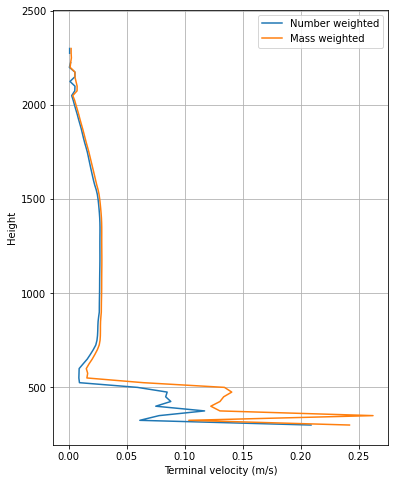

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

ds = xr.open_dataset("/data1/pappu/KiD-A/output/KiD_m-TAU_bin_u-Pappu_Paul_c-0101_v-0003.nc")
# -----------------------------
# Read variables
# -----------------------------
rho = ds["density"].values               # (z,time)
N   = ds["cloud_bin_number"].values      # (z,bins,time)
M   = ds["cloud_bin_mass"].values        # (z,bins,time)

# Check units of bins_D !
D = ds["bins_D"].values* 1e-6                  # (bins,)

# If bins_D is in microns uncomment:
# D = D * 1e-6

# -----------------------------
# Terminal velocity parameters
# MG08 cloud droplet relation
# V(D) = a D^b
# -----------------------------
rho0 = 1.225

a = 3.0e7
b = 2.0

# -----------------------------
# Calculate V(D)
# -----------------------------
Vbin = (
    (rho[:, :, None] / rho0)**0.54
    * a
    * D[None, None, :]**b
)

# Current shape:
# (z,time,bins)

# Convert to:
# (z,bins,time)

Vbin = np.transpose(Vbin, (0,2,1))

print("Vbin shape =",Vbin.shape)
print("N shape    =",N.shape)
print("M shape    =",M.shape)

# -----------------------------
# Number-weighted velocity
# -----------------------------
VN_num = np.sum(N * Vbin, axis=1)
VN_den = np.sum(N, axis=1)

VN = np.divide(
    VN_num,
    VN_den,
    out=np.full_like(VN_num, np.nan),
    where=VN_den>0
)

# -----------------------------
# Mass-weighted velocity
# -----------------------------
VQ_num = np.sum(M * Vbin, axis=1)
VQ_den = np.sum(M, axis=1)

VQ = np.divide(
    VQ_num,
    VQ_den,
    out=np.full_like(VQ_num, np.nan),
    where=VQ_den>0
)

print("VN shape =",VN.shape)
print("VQ shape =",VQ.shape)

# -----------------------------
# Sanity check
# -----------------------------
print("VN min/max =",np.nanmin(VN),np.nanmax(VN))
print("VQ min/max =",np.nanmin(VQ),np.nanmax(VQ))

# -----------------------------
# Plot final-time profile
# -----------------------------
z = ds["z"].values

itime = 59

plt.figure(figsize=(6,8))
plt.plot(VN[:,itime],z,label="Number weighted")
plt.plot(VQ[:,itime],z,label="Mass weighted")
plt.xlabel("Terminal velocity (m/s)")
plt.ylabel("Height")
plt.legend()
plt.grid()
plt.show()

/tmp/ipykernel_1643646/1216024751.py:2: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(VN, axis=0),label="Number weighted")
/tmp/ipykernel_1643646/1216024751.py:3: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(VQ, axis=0),label="Mass weighted")


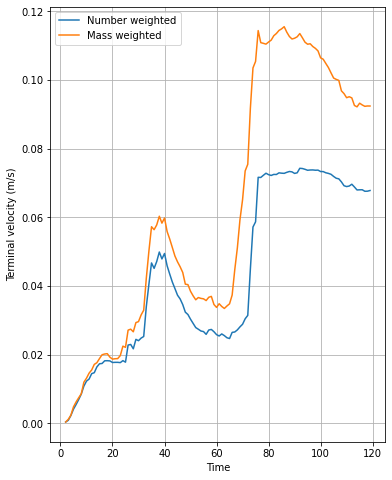

In [4]:
plt.figure(figsize=(6,8))
plt.plot(np.nanmean(VN, axis=0),label="Number weighted")
plt.plot(np.nanmean(VQ, axis=0),label="Mass weighted")
plt.ylabel("Terminal velocity (m/s)")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.show()

Vbin shape = (120, 34, 360)
N shape    = (120, 34, 360)
M shape    = (120, 34, 360)
VN shape = (120, 360)
VQ shape = (120, 360)
VN min/max = -0.05644023 2.4317043
VQ min/max = -0.0058489004 2.4317033


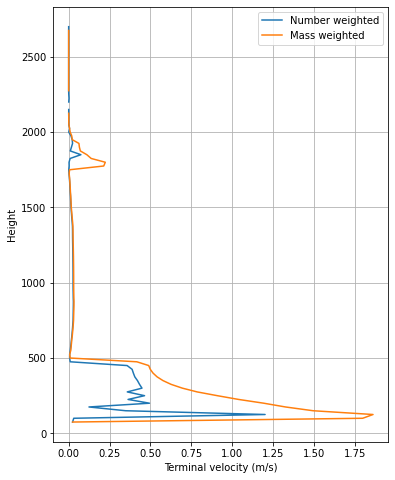

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

ds = xr.open_dataset("/data1/pappu/KiD-A/output/KiD_m-TAU_bin_u-Pappu_Paul_c-0103_v-0002.nc")
# -----------------------------
# Read variables
# -----------------------------
rho = ds["density"].values               # (z,time)
N   = ds["cloud_bin_number"].values      # (z,bins,time)
M   = ds["cloud_bin_mass"].values        # (z,bins,time)

# Check units of bins_D !
D = ds["bins_D"].values* 1e-6                  # (bins,)

# If bins_D is in microns uncomment:
# D = D * 1e-6

# -----------------------------
# Terminal velocity parameters
# MG08 cloud droplet relation
# V(D) = a D^b
# -----------------------------
rho0 = 1.225

a = 3.0e7
b = 2.0

# -----------------------------
# Calculate V(D)
# -----------------------------
Vbin = (
    (rho[:, :, None] / rho0)**0.54
    * a
    * D[None, None, :]**b
)

# Current shape:
# (z,time,bins)

# Convert to:
# (z,bins,time)

Vbin = np.transpose(Vbin, (0,2,1))

print("Vbin shape =",Vbin.shape)
print("N shape    =",N.shape)
print("M shape    =",M.shape)

# -----------------------------
# Number-weighted velocity
# -----------------------------
VN_num = np.sum(N * Vbin, axis=1)
VN_den = np.sum(N, axis=1)

VN = np.divide(
    VN_num,
    VN_den,
    out=np.full_like(VN_num, np.nan),
    where=VN_den>0
)

# -----------------------------
# Mass-weighted velocity
# -----------------------------
VQ_num = np.sum(M * Vbin, axis=1)
VQ_den = np.sum(M, axis=1)

VQ = np.divide(
    VQ_num,
    VQ_den,
    out=np.full_like(VQ_num, np.nan),
    where=VQ_den>0
)

print("VN shape =",VN.shape)
print("VQ shape =",VQ.shape)

# -----------------------------
# Sanity check
# -----------------------------
print("VN min/max =",np.nanmin(VN),np.nanmax(VN))
print("VQ min/max =",np.nanmin(VQ),np.nanmax(VQ))

# -----------------------------
# Plot final-time profile
# -----------------------------
z = ds["z"].values

itime = 179

plt.figure(figsize=(6,8))
plt.plot(VN[:,itime],z,label="Number weighted")
plt.plot(VQ[:,itime],z,label="Mass weighted")
plt.xlabel("Terminal velocity (m/s)")
plt.ylabel("Height")
plt.legend()
plt.grid()
plt.show()

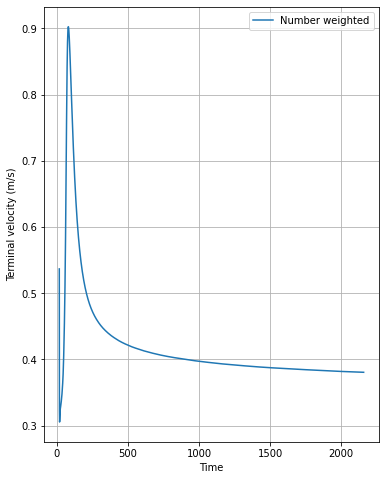

In [71]:
plt.figure(figsize=(6,8))
plt.plot(VN[40,:],label="Number weighted")
#plt.plot(VQ,label="Mass weighted")
plt.ylabel("Terminal velocity (m/s)")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.show()

VN min/max = 0.34083164 0.49627456
VQ min/max = 1.0879346 1.5841084


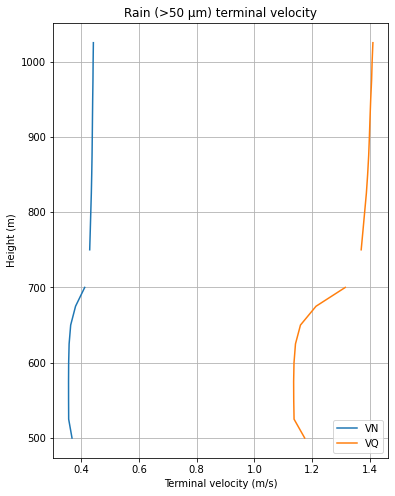

In [48]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# =====================================
# Open file
# =====================================

ds = xr.open_dataset(
    "/data1/pappu/KiD-A/output/KiD_m-TAU_bin_u-Pappu_Paul_c-0101_v-0001.nc"
)

# =====================================
# Variables
# =====================================

rho = ds["density"].values

qr = ds["rain_mass_50um"].values      # kg/kg
Nr = ds["rain_number_50um"].values    # #/kg

z = ds["z"].values

# =====================================
# Constants
# =====================================

rho_w = 1000.0
rho0 = 1.225

mu = 0.0

# MG08 rain parameters
a = 841.997
b = 0.8

# =====================================
# Avoid divide by zero
# =====================================

qr_safe = np.maximum(qr, 1e-30)
Nr_safe = np.maximum(Nr, 1e-30)

# =====================================
# Lambda
# =====================================

lam = (
    np.pi * rho_w * Nr_safe * gamma(4 + mu)
    / (6.0 * qr_safe * gamma(1 + mu))
) ** (1.0 / 3.0)

# =====================================
# Mass-weighted terminal velocity
# Eq. 18 MG08
# =====================================

VQ = (
    (rho / rho0)**0.54
    * a
    * gamma(4 + b + mu)
    / (lam**b * gamma(4 + mu))
)

# =====================================
# Number-weighted terminal velocity
# Eq. 17 MG08
# =====================================

VN = (
    (rho / rho0)**0.54
    * a
    * gamma(1 + b + mu)
    / (lam**b * gamma(1 + mu))
)

# mask rain-free points
VQ[qr < 1e-12] = np.nan
VN[qr < 1e-12] = np.nan

print("VN min/max =", np.nanmin(VN), np.nanmax(VN))
print("VQ min/max =", np.nanmin(VQ), np.nanmax(VQ))

# =====================================
# Plot
# =====================================

itime = -1

plt.figure(figsize=(6,8))

plt.plot(VN[:,itime], z, label="VN")
plt.plot(VQ[:,itime], z, label="VQ")

plt.xlabel("Terminal velocity (m/s)")
plt.ylabel("Height (m)")
plt.title("Rain (>50 μm) terminal velocity")
plt.legend()
plt.grid()

plt.show()

rho min/max = 0.8674136 1.1671197
lambda min/max = 14.645921 18364.469
VQ min/max = 0.82472456 7.130166
VN min/max = 0.25837234 2.2337613


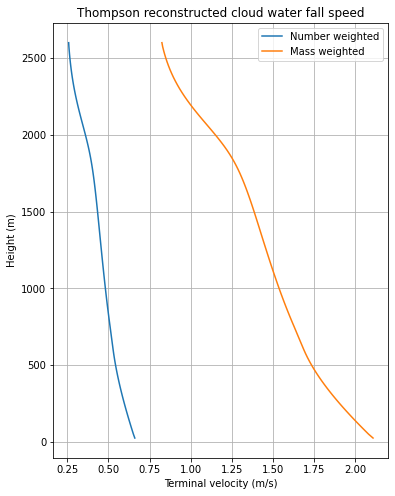

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

ds = xr.open_dataset("/data1/pappu/KiD-A/output/KiD_m-thompson09_u-Put_Your_Name_Here_c-0101_v-0002.nc")
ds
# =====================================================
# Read Thompson output
# =====================================================

p  = ds["pressure"].values * 100      # Pa
T  = ds["temperature"].values   # K

qr = ds["rain_mass"].values     # kg/kg
Nr = ds["rain_number"].values   # #/kg

z  = ds["z"].values

# =====================================================
# Air density
# =====================================================

Rd = 287.05

rho = p / (Rd * T)

print("rho min/max =", np.nanmin(rho), np.nanmax(rho))

# =====================================================
# Constants
# =====================================================

rho_w = 1000.0
rho0  = 1.225

mu = 0.0

# MG08 rain parameters
a = 841.997
b = 0.8
#a = 3.0e7
#b = 2.0

# =====================================================
# Avoid divide-by-zero
# =====================================================

qr_safe = np.maximum(qr, 1e-30)
Nr_safe = np.maximum(Nr, 1e-30)

# =====================================================
# Lambda (rain PSD slope)
# =====================================================

lam = (
    np.pi * rho_w * Nr_safe * gamma(4 + mu)
    / (6.0 * qr_safe * gamma(1 + mu))
) ** (1.0/3.0)

print("lambda min/max =", np.nanmin(lam), np.nanmax(lam))

# =====================================================
# Mass-weighted terminal velocity
# MG08 Eq. (18)
# =====================================================

VQ = (
    (rho / rho0)**0.54
    * a
    * gamma(4 + b + mu)
    / (lam**b * gamma(4 + mu))
)

# Remove rain-free levels
VQ[qr < 1e-10] = np.nan

print("VQ min/max =", np.nanmin(VQ), np.nanmax(VQ))

# =====================================================
# Number-weighted terminal velocity
# MG08 Eq. (17)
# =====================================================

VN = (
    (rho / rho0)**0.54
    * a
    * gamma(1 + b + mu)
    / (lam**b * gamma(1 + mu))
)

VN[qr < 1e-10] = np.nan

print("VN min/max =", np.nanmin(VN), np.nanmax(VN))

# =====================================================
# Plot final profile
# =====================================================

itime = 238

plt.figure(figsize=(6,8))

plt.plot(VN[:,itime], z, label="Number weighted")
plt.plot(VQ[:,itime], z, label="Mass weighted")
plt.xlabel("Terminal velocity (m/s)")
plt.ylabel("Height (m)")
plt.title("Thompson reconstructed cloud water fall speed")
plt.legend()
plt.grid()

plt.show()

/tmp/ipykernel_1344892/1216024751.py:2: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(VN, axis=0),label="Number weighted")
/tmp/ipykernel_1344892/1216024751.py:3: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(VQ, axis=0),label="Mass weighted")


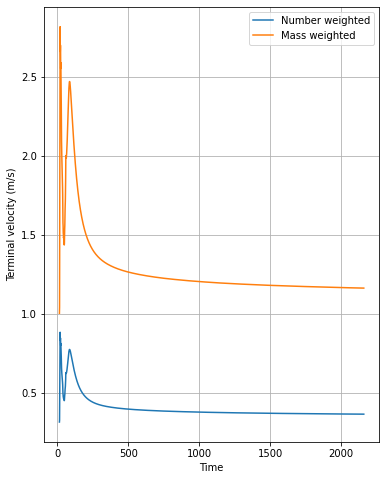

In [65]:
plt.figure(figsize=(6,8))
plt.plot(np.nanmean(VN, axis=0),label="Number weighted")
plt.plot(np.nanmean(VQ, axis=0),label="Mass weighted")
plt.ylabel("Terminal velocity (m/s)")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.show()

In [49]:
ds = xr.open_dataset("/data1/pappu/KiD-A/output/KiD_m-thompson09_u-Put_Your_Name_Here_c-0101_v-0002.nc")
ds

<xarray.Dataset> Size: 33MB
Dimensions:                  (z: 120, x: 1, time: 2160)
Coordinates:
  * z                        (z) float32 480B 25.0 50.0 75.0 ... 2.975e+03 3e+03
  * x                        (x) float32 4B 0.0
  * time                     (time) float32 9kB 10.0 20.0 ... 2.159e+04 2.16e+04
Data variables: (12/40)
    surface_ppt_for_rain     (time) float32 9kB ...
    surface_ppt_for_ice      (time) float32 9kB ...
    surface_ppt_for_snow     (time) float32 9kB ...
    surface_ppt_for_graupel  (time) float32 9kB ...
    total_surface_ppt        (time) float32 9kB ...
    cloud_mass_path          (time) float32 9kB ...
    ...                       ...
    prr_rcw                  (z, time) float32 1MB ...
    prv_rev                  (z, time) float32 1MB ...
    pnr_wau                  (z, time) float32 1MB ...
    pnr_rev                  (z, time) float32 1MB ...
    pnr_rcr                  (z, time) float32 1MB ...
    precip_level             (z, time) float32 1MB ...
Attributes:
    title:             Microphysics dataset produced by KiD model version !Ve...
    creation date:    Date 28/05/2026; time 15:24:02-0400 UTC
    User:             Put Your Name Here
    Institution:      
    Microphysics ID:  thompson09
    Advection ID:     LEM2.4
    references:       
    comments:

In [11]:
print(ds["bins_D"].values[:10])
print(ds["bins_D"].attrs)

[ 3.5772305  4.5070276  5.678499   7.154461   9.014055  11.356999
 14.308922  18.028112  22.713999  28.617846 ]
{'units': 'microns', 'dim': 'nbins'}


In [12]:
print("qc min/max =", np.nanmin(qc), np.nanmax(qc))
print("Nc min/max =", np.nanmin(Nc), np.nanmax(Nc))

print("lambda min/max =", np.nanmin(lam), np.nanmax(lam))

print("V_morrison min/max =", np.nanmin(V_morrison), np.nanmax(V_morrison))

qc min/max = 1e-30 0.0013967846
Nc min/max = 1e-30 157467200.0
lambda min/max = 0.007332118 25183568.0
V_morrison min/max = 8.881078e-07 9818240000000.0


In [13]:
print(ds["cloud_bin_mass"].attrs)
print(ds["cloud_bin_number"].attrs)

{'units': 'kg/kg', 'dim': 'z,bin'}
{'units': '/kg', 'dim': 'z,bin'}
